# Case 1: Optimizing Spark Joins with Broadcast Joins

## Introduction

In this case study, we will analyze the impact of different join strategies in Apache Spark using two tables:

- **Fact_Transaction**
- **Dim_Stores**

The objective is to understand how Spark executes joins and compare the performance of a standard join versus a Broadcast Join. We will also analyze the execution plans and Spark UI to understand what happens behind the scenes.

For this experiment, we will use a small cluster.

### Cluster Configuration

#### Executors
- 2 executor nodes
- 2 CPU cores per executor
- 1 GB RAM per executor

#### Driver
- 1 driver node
- 1 CPU core
- 1 GB RAM

---

## Why This Matters

Most of the time, we only see a successful job execution and assume everything is working efficiently.

However, a job can complete successfully while still consuming unnecessary resources, performing excessive shuffling, or taking longer than required.

As Data Engineers, it is important not only to make jobs run, but also to understand how Spark executes them and identify opportunities for optimization.

In this case study, we will use Spark's execution plans and Spark UI to investigate the behavior of different join strategies and measure their impact on performance.

---

## Scenario

We will simulate a join between a large fact table and a small dimension table using a dataset with a skewed key distribution.

The analysis will focus on:

- Physical execution plans
- DAG visualization
- Shuffle operations
- Stage execution
- Broadcast Join behavior
- Performance differences between join strategies

By the end of this study, we will understand when a Broadcast Join is beneficial and how it can significantly reduce the cost of a join operation in Spark.


# Init Spark Cluster

In [1]:
from init_spark import spark_session
from pyspark.sql.functions import *

spark = spark_session()

Spark UI: http://localhost:4040


# Read DataFrames

In [ ]:
spark.sparkContext.setJobDescription('Read_Fact')

try:
    Fact_Transaction = spark.read.format("delta").load(r"C:\Users\tfcosta\Lab\Bronze\fact_transaction")
except Exception as e:
    print("Error loading Fact_Transaction:", e)

In [3]:
spark.sparkContext.setJobDescription('Read_Dim')
try:
    Dim_Store = spark.read.format("delta").load(r"C:\Users\tfcosta\Lab\Bronze\dim_stores")
except Exception as e:
    print("Error loading Dim_Store:", e)

# See the partitions of each delta

In [4]:
spark.sparkContext.setJobDescription('Partition_Fact')

Fact_Transaction.rdd.getNumPartitions()

13

In [5]:
spark.sparkContext.setJobDescription('Partition_Dim')

Dim_Store.rdd.getNumPartitions()

1

# Distribution of dataset to detection if will have or not data skew

In [6]:
def profile_key_distribution(df : DataFrame, key : str) -> DataFrame:
    '''
    This function profiles the distribution of a key in a DataFrame by calculating the count of rows for each 
    key value and then computing various statistics on these counts, 
    including the number of distinct keys, average count, percentiles (25th, 50th, 75th, 90th, 99th), and the maximum count.

     Parameters:
      df (DataFrame): The input DataFrame to be profiled.
    key (str): The column name of the key to be profiled.
     
     Returns:
      DataFrame: A DataFrame containing the distribution statistics of the key.
    '''
    counts = (
        df.groupBy(key)
          .count()
    )

    return (
        counts.agg(
            count("*").alias("distinct_keys"),
            avg("count").alias("avg"),
            expr("percentile_approx(count, 0.25)").alias("p25"),
            expr("percentile_approx(count, 0.50)").alias("p50"),
            expr("percentile_approx(count, 0.75)").alias("p75"),
            expr("percentile_approx(count, 0.90)").alias("p90"),
            expr("percentile_approx(count, 0.99)").alias("p99"),
            max("count").alias("max")
        )
    )

Fact_profile = profile_key_distribution(Fact_Transaction, "Store_id")
Dim_Store_profile = profile_key_distribution(Dim_Store, "Store_id")

spark.sparkContext.setJobDescription('Profile_Fact')
Fact_profile.show()

spark.sparkContext.setJobDescription('Profile_Dim')
Dim_Store_profile.show()


"""
This output shows a severe data skew on the 'store_id' join key.

- 25% of the store_id values have 26 or fewer rows.
- 50% of the store_id values have 29 or fewer rows.
- 75% of the store_id values have 33 or fewer rows.
- 90% of the store_id values have 36 or fewer rows.
- 99% of the store_id values have 43 or fewer rows.

However, the largest store_id contains 23,610,925 rows.

This indicates an extremely skewed key distribution, where almost all keys contain only a few dozen rows, 
while one key contains millions of rows and this will cause long-running tasks, and memory/disk spills during joins or aggregations.
"""

+-------------+------+---+---+---+---+---+--------+
|distinct_keys|   avg|p25|p50|p75|p90|p99|     max|
+-------------+------+---+---+---+---+---+--------+
|        50000|1800.0| 26| 29| 33| 36| 43|23610925|
+-------------+------+---+---+---+---+---+--------+

+-------------+---+---+---+---+---+---+---+
|distinct_keys|avg|p25|p50|p75|p90|p99|max|
+-------------+---+---+---+---+---+---+---+
|        50000|1.0|  1|  1|  1|  1|  1|  1|
+-------------+---+---+---+---+---+---+---+



"\nThis output shows a severe data skew on the 'store_id' join key.\n\n- 25% of the store_id values have 26 or fewer rows.\n- 50% of the store_id values have 29 or fewer rows.\n- 75% of the store_id values have 33 or fewer rows.\n- 90% of the store_id values have 36 or fewer rows.\n- 99% of the store_id values have 43 or fewer rows.\n\nHowever, the largest store_id contains 23,610,925 rows.\n\nThis indicates an extremely skewed key distribution, where almost all keys contain only a few dozen rows, \nwhile one key contains millions of rows and this will cause long-running tasks, and memory/disk spills during joins or aggregations.\n"

In [ ]:
spark.sparkContext.setJobDescription('Distribution_Fact')

Fact_Transaction \
    .groupBy("Store_id") \
    .count() \
    .orderBy(desc("count")) \
    .show(10, False)

'''
This output confirms the extreme skew on the 'store_id' key in the fact table. 
The top 5 store_ids values have counts ranging from 23,610,925 down to 11,000,000 rows, 
after that the number decreases drastically from millions of rows and to just a few dozen rows for the majority of store_ids.
'''

+--------+--------+
|Store_id|count   |
+--------+--------+
|0       |23610925|
|1       |20651604|
|2       |17705183|
|3       |14756030|
|4       |11803521|
|28756   |56      |
|45603   |54      |
|28066   |53      |
|46816   |52      |
|12174   |52      |
+--------+--------+
only showing top 10 rows



"\nThis output confirms the extreme skew on the 'store_id' key in the fact table. \nThe top 4 store_ids values have counts ranging from 23,610,925 down to 11,000,000 rows, \nafter that the number decreases drastically from millions of rows and to just a few dozen rows for the majority of store_ids.\n"

In [ ]:
spark.sparkContext.setJobDescription('Distribution_Dim_Store')

Dim_Store \
    .groupBy("Store_id") \
    .count() \
    .orderBy(desc("count")) \
    .show(10, False)

'''
Has we can see that the dimension table has a uniform distribution of store_id values.
'''

+--------+-----+
|Store_id|count|
+--------+-----+
|26      |1    |
|29      |1    |
|474     |1    |
|964     |1    |
|1677    |1    |
|1697    |1    |
|1806    |1    |
|1950    |1    |
|2040    |1    |
|2214    |1    |
+--------+-----+
only showing top 10 rows



"\nThis output confirms the extreme skew on the 'store_id' key in the fact table. \nThe top 4 store_ids values have counts ranging from 23,610,925 down to 11,000,000 rows, \nafter that the number decreases drastically from millions of rows and to just a few dozen rows for the majority of store_ids.\n"

---

# Sort Merge Join

### Make a Join Between Fact and Dimension with All Spark Optimizations Disabled

For better understanding, we will disable several Spark optimizations, including:

- Adaptive Query Execution (AQE)
- Broadcast Join
- Coalesce Partitions
- Skew Join Optimization

If these settings are enabled, Spark will automatically try to determine the most efficient execution plan for the join. However, our goal is to understand what happens behind the scenes during a Spark job execution, so we will disable these optimizations and analyze the behavior manually.


In [9]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)
spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False )
spark.conf.set("spark.sql.adaptive.skewJoin.enabled", False)

In [10]:
import time

start_time = time.time()

spark.sparkContext.setJobDescription('Join_Deltas_Without_Broadcast')

Df_Joined = Fact_Transaction.join(Dim_Store, on="store_id", how="inner")

Df_Joined.write.format("noop").mode("overwrite").save() # Trigger the execution of the join without writing to storage

end_time = time.time()
print(f"Time of execution: {end_time - start_time} seconds")

Time of execution: 48.11679744720459 seconds


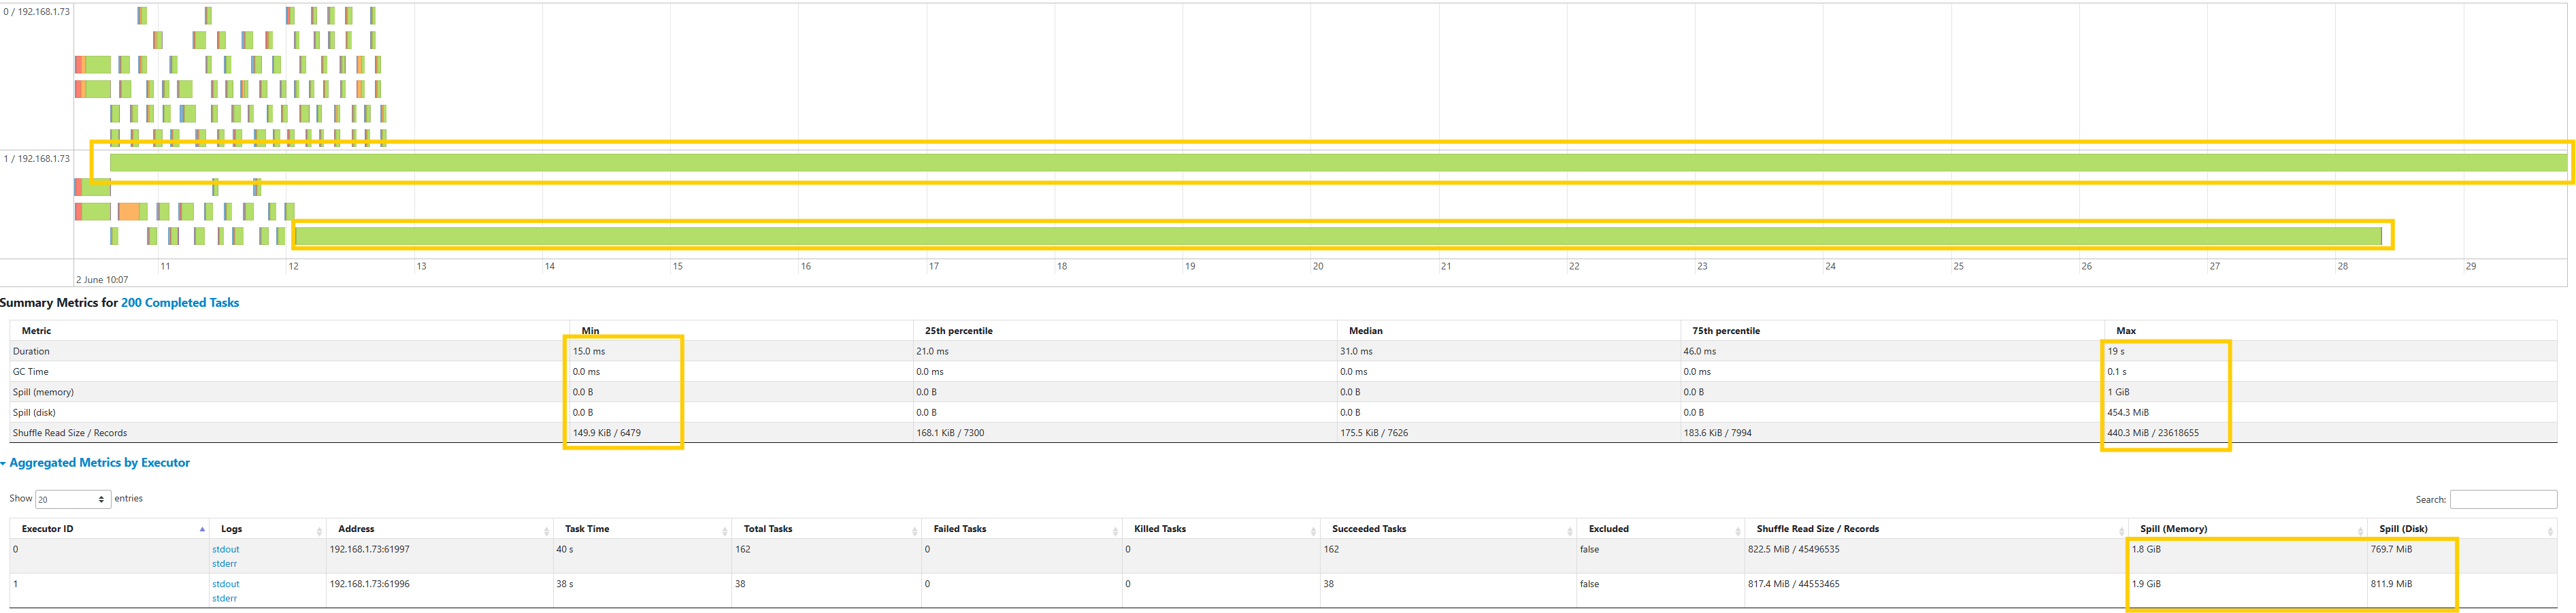

#### Key Performance Issues

- **Data Skew**: A few partitions are much larger than others, causing some tasks to run significantly longer.
- **Memory Spill**: Spark exceeded available memory and spilled data during processing.
- **Disk Spill**: Additional data was written to disk, increasing I/O and slowing execution.
- **Uneven Shuffle**: Some tasks processed only KBs of data while others processed hundreds of MBs.
- **Straggler Tasks**: A small number of slow tasks delayed the completion of the entire stage.

#### Root Cause

The join produced **skewed partitions**, resulting in large shuffle operations, memory pressure, spill events, and long-running tasks.


---

# BroadcastJoin

##### Make a Join between Fact and Dim with all configuration for spark optimization enabled

In [11]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", 10 * 1024 * 1024) # 10MB
spark.conf.set("spark.sql.adaptive.enabled", True)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", True )
spark.conf.set("spark.sql.adaptive.skewJoin.enabled", True)

#### Spark Join Optimization Settings

##### spark.sql.autoBroadcastJoinThreshold = 10MB
- Automatically broadcasts tables up to **10 MB**.
- Avoids shuffle for small dimension tables.
- Improves join performance by reducing network I/O.

##### spark.sql.adaptive.enabled = true

- Enables **Adaptive Query Execution (AQE)**.
- Optimizes query plans based on runtime statistics.
- Can dynamically adjust join strategies and shuffle operations.


##### spark.sql.adaptive.coalescePartitions.enabled = true
- Merges small shuffle partitions.
- Reduces the number of tasks and scheduling overhead.
- Improves execution efficiency.

##### spark.sql.adaptive.skewJoin.enabled = true
- Detects and mitigates data skew.
- Splits large skewed partitions.
- Balances workload and reduces execution bottlenecks.

##### Summary

Together, these settings help Spark execute joins more efficiently by reducing shuffle, adapting execution plans at runtime, optimizing partition sizes, and handling skewed data automatically.

In [12]:
"""
This will show to us the size of the table we want to join, 
and if it is smaller than the threshold, it will be broadcasted to all the nodes

"""

Dim_Store.explain("cost")

== Optimized Logical Plan ==
Relation [store_id#68L,brand#69,region#70] parquet, Statistics(sizeInBytes=228.4 KiB)

== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [store_id#68L,brand#69,region#70] Batched: true, DataFilters: [], Format: Parquet, Location: PreparedDeltaFileIndex(1 paths)[file:/C:/Users/tfcosta/Lab/Bronze/dim_stores], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<store_id:bigint,brand:string,region:string>




In [13]:
import time

start_time = time.time()

spark.sparkContext.setJobDescription('Join_Deltas_With_Broadcast')

Df_Joined_Broadcasted = Fact_Transaction.join(Dim_Store, on="store_id", how="inner")

Df_Joined_Broadcasted.write.format("noop").mode("overwrite").save() # Trigger the execution of the join without writing to storage

end_time = time.time()
print(f"Time of execution: {end_time - start_time} seconds")

Time of execution: 7.053684234619141 seconds


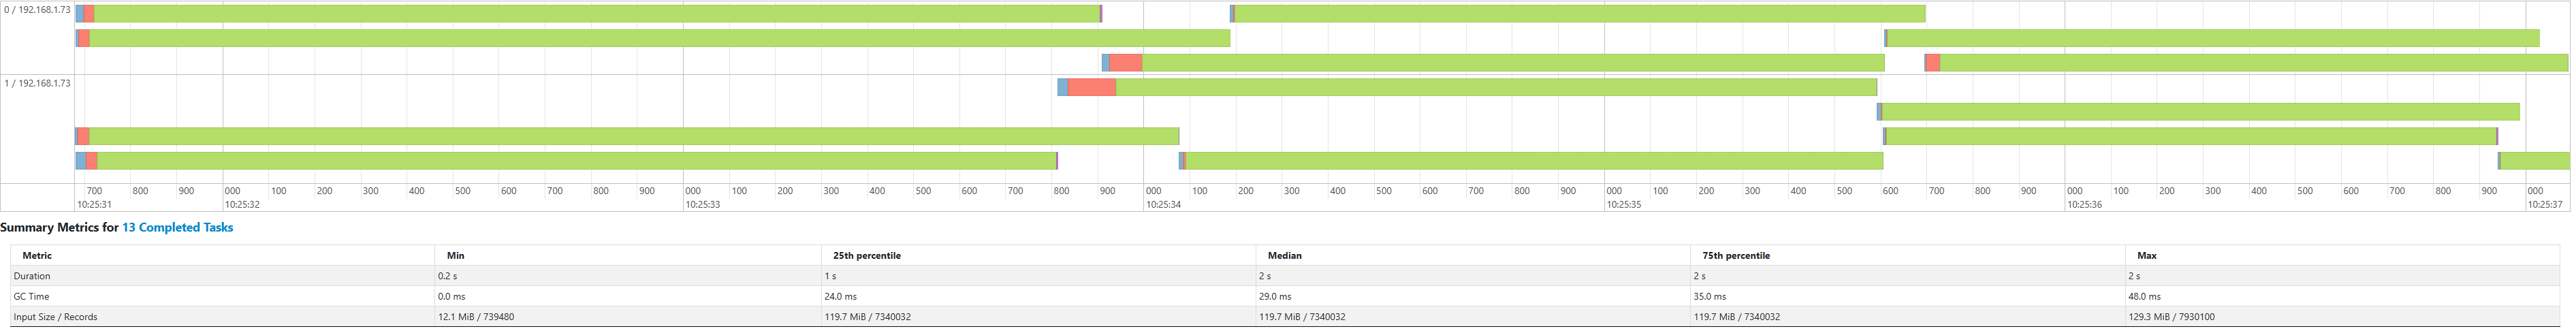

## Results with Broadcast Join, AQE, and Skew Optimization Enabled

After enabling **Broadcast Join**, **Adaptive Query Execution (AQE)**, and **Skew Join Optimization**, the execution became significantly more balanced.

### Improvements Observed

- **No visible data skew**: task durations are much more uniform across executors.
- **Reduced execution time**: the stage completes faster because Spark avoids long-running straggler tasks.
- **No significant spill activity**: memory and disk spills were eliminated or greatly reduced.
- **Better workload distribution**: tasks process similar amounts of data, improving parallelism.
- **Reduced shuffle overhead**: the broadcasted dimension table eliminates the need for a large shuffle during the join.

### Why It Improved

Spark automatically optimized the execution plan by:

- Using a **Broadcast Hash Join** for the small dimension table.
- Applying **AQE** to adjust the physical plan based on runtime statistics.
- Detecting and mitigating skewed partitions through **Skew Join Optimization**.
- Optimizing partition sizes to improve resource utilization.

### Comparison with the Previous Execution

| Disabled Optimizations | Enabled Optimizations |
|-----------------------|----------------------|
| Severe data skew | Balanced workload |
| Large shuffle operations | Reduced shuffle |
| Memory and disk spills | Minimal or no spills |
| Long-running straggler tasks | Uniform task duration |
| Slow stage completion | Faster execution |

### Conclusion

The previous execution exposed the impact of data skew on a Sort-Merge Join. By enabling Broadcast Join, AQE, and Skew Join Optimization, Spark automatically mitigated these issues, resulting in a more efficient, balanced, and faster execution plan.

---

## Key Takeaways
A Spark job running successfully does not necessarily mean it is running efficiently.

Understanding execution plans, shuffle operations, and join strategies is essential for building scalable and cost-effective data pipelines.

By analyzing the Spark UI and physical execution plans, we can make informed decisions that significantly improve performance while reducing resource consumption.

Keep the following points in mind:

* **Shuffle is not always bad.** It is a fundamental operation in Spark and is often required for joins and aggregations. However, when data skew exists, shuffle operations can lead to performance issues, as demonstrated in the Sort-Merge Join example.

* **Broadcast Join can significantly improve performance** by avoiding large shuffle operations. However, it should be used carefully, taking into account both the size of the DataFrame and the available memory on the executors.

* When using a Broadcast Join, Spark sends the broadcasted DataFrame to every executor in the cluster. If the DataFrame is too large or executor memory is insufficient, this can result in **Out Of Memory (OOM)** errors.

* As a general rule, **Broadcast Join should only be used when the DataFrame is small enough to fit comfortably in the memory of every executor**.

* Spark features such as **Adaptive Query Execution (AQE)** and **Skew Join Optimization** can automatically detect and mitigate data skew, helping to distribute work more evenly and improve overall query performance.

    

## Results Summary

| Scenario | Execution Time | Join Strategy | Main Issue |
|---|---:|---|---|
| Without Broadcast / AQE disabled | 48.1s | Sort Merge Join | Shuffle + skew + spills |
| With Broadcast / AQE enabled | 7.05s | Broadcast Hash Join | Much lower shuffle overhead |

The optimized version was approximately **6.8x faster**.